In [178]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [179]:
df = pd.read_csv('placement.csv')

In [180]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package (LPA)')

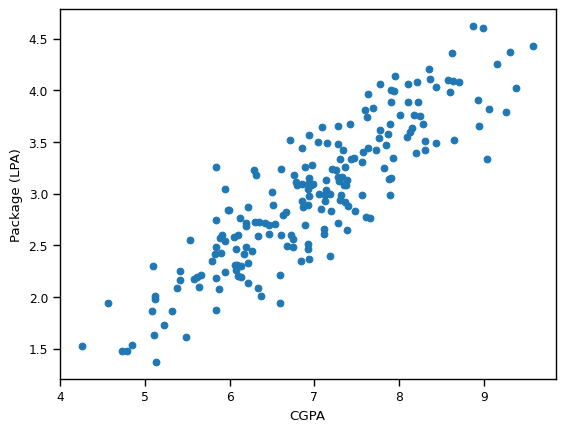

In [181]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package (LPA)')

In [182]:
x  = df.iloc[:, 0:1]
y = df.iloc[:,-1]

In [183]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=2)

In [184]:
from sklearn.linear_model import LinearRegression

In [185]:
lr = LinearRegression()

In [186]:
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [187]:
x_test

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57
85,4.79
10,5.32
54,6.86
115,8.35
35,6.87


In [188]:
y_test

112    4.10
29     3.49
182    2.08
199    2.33
193    1.94
85     1.48
10     1.86
54     3.09
115    4.21
35     2.87
12     3.65
92     4.00
13     2.89
126    2.60
174    2.99
2      3.25
44     1.86
3      3.67
113    2.37
14     3.42
23     2.48
25     3.65
6      2.60
134    2.83
165    4.08
173    2.56
45     3.58
65     3.81
48     4.09
122    2.01
178    3.63
64     2.92
9      3.51
57     1.94
78     2.21
71     3.34
128    3.34
176    3.23
131    2.01
53     2.61
Name: package, dtype: float64

In [189]:
lr.predict(x_test.iloc[0].values.reshape(1,1))

c:\Users\karan.chawla\Desktop\python-programming\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.89111601])

In [190]:
lr.predict(x_test.iloc[2].values.reshape(1,1))

c:\Users\karan.chawla\Desktop\python-programming\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.38464568])

Text(0, 0.5, 'Package (LPA)')

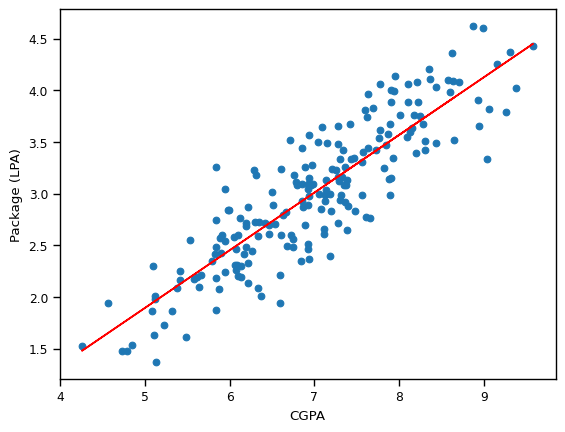

In [191]:
plt.scatter(df['cgpa'], df['package'])
plt.plot(x_train, lr.predict(x_train), color='red')
plt.xlabel('CGPA')
plt.ylabel('Package (LPA)')

In [192]:
m = lr.coef_
m

array([0.55795197])

In [193]:
c = lr.intercept_
c

np.float64(-0.8961119222429144)

In [194]:
# y = mx + c
m * 8.58 + c
# this is basically what is happening BTS

array([3.89111601])

## Model Evaluation <br>
MSE, MAE, RMSE, R2 Score

In [195]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [196]:
y_pred = lr.predict(x_test)

In [197]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [198]:
print(f"MAE: {mean_absolute_error(y_test ,y_pred)}")

MAE: 0.2884710931878175


In [199]:
print(f"MSE: {mean_squared_error(y_test, y_pred)}")

MSE: 0.12129235313495527


In [200]:
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

RMSE: 0.34827051717731616


In [201]:
r2 = r2_score(y_test, y_pred)
print(f"R2 Score: {r2}")

R2 Score: 0.780730147510384


In [202]:
print(x_test.shape)
ad_r2 = 1 - ((1-r2)*(40-1)/(40-1-1))
print(f"Adjusted R2 Score: {ad_r2}")

(40, 1)
Adjusted R2 Score: 0.7749598882343415


## Trying LR with own dataset

In [203]:
data = {"Area (sqft)":[1100, 1200, 1400, 1600, 2000, 2900], "Bedrooms":[1,1,2,1,2,3], "Rent":[21,23,32,30,27,45]}
df2 = pd.DataFrame(data=data)

In [204]:
a = df2.iloc[:,0:2]
a

,Area (sqft),Bedrooms
0,1100,1
1,1200,1
2,1400,2
3,1600,1
4,2000,2
5,2900,3


In [205]:
b = df2.iloc[:,2]
b

0    21
1    23
2    32
3    30
4    27
5    45
Name: Rent, dtype: int64

In [206]:
#a_train, a_test, b_train, b_test = train_test_split(a,b, test_size=0.2, random_state=42)
# last 2 rows → test
a_test = a.iloc[-2:]
b_test = b.iloc[-2:]

# rest → train
a_train = a.iloc[:-2]
b_train = b.iloc[:-2]

In [207]:
model = LinearRegression()
model.fit(a_train, b_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [208]:
predicted = model.predict(a_test)

In [209]:
print(a_test.shape)
print(b_test.shape)

(2, 2)
(2,)


In [210]:
a_test

,Area (sqft),Bedrooms
4,2000,2
5,2900,3


In [211]:
predicted

array([42.71428571, 64.33333333])

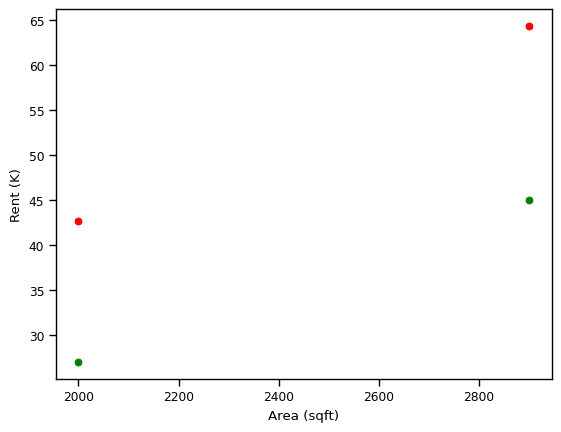

In [212]:
plt.scatter(a_test['Area (sqft)'], b_test, color='green')
plt.scatter(a_test['Area (sqft)'], predicted, color='red')
plt.xlabel("Area (sqft)")
plt.ylabel("Rent (K)")
plt.show()

# #FLOP

## Let's try again

In [213]:
np.random.seed(42)

n = 50

area = np.random.randint(800, 3000, n)
bedrooms = np.random.randint(1, 4, n)

# create realistic rent with some noise
rent = (area * 0.02) + (bedrooms * 5) + np.random.normal(0, 3, n)

df3 = pd.DataFrame({
    "Area (sqft)": area,
    "Bedrooms": bedrooms,
    "Rent": rent
})

df3

,Area (sqft),Bedrooms,Rent
0,1660,2,45.637577
1,2094,2,55.948720
2,1930,2,48.383970
3,1895,2,50.910599
4,2438,2,59.844908
5,2969,2,67.444641
6,1266,3,41.404187
7,2038,3,60.374110
8,1130,2,32.492522
9,2282,3,65.333931


In [214]:
x = df3.iloc[:, 0:1]
y = df3.iloc[:, 2]
print(x.shape)
print(y.shape)

(50, 1)
(50,)


In [215]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=42)

In [216]:
model2 = LinearRegression()

In [217]:
model2.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [218]:
predicted2 = model2.predict(x_test)

In [219]:
x_train.shape
predicted2.shape

(15,)

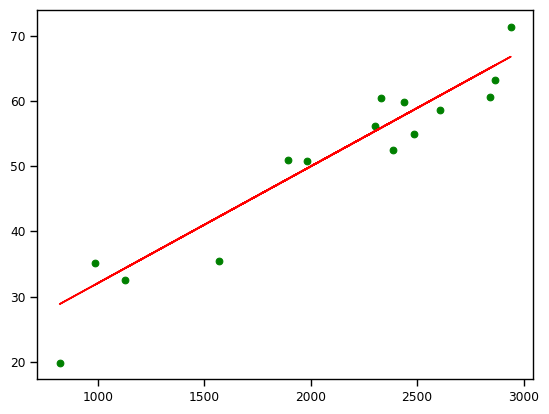

In [220]:
plt.scatter(x_test['Area (sqft)'], y_test, color='green')
plt.plot(x_test['Area (sqft)'], predicted2, color='red')

## Now let's try using both features and model evaluation instead of plotting

In [221]:
a = df3.iloc[:, 0:2]
b = df3.iloc[:, 2]

In [222]:
a_train, a_test, b_train, b_test = train_test_split(a, b, test_size=0.3, random_state=42)

In [223]:
model3 = LinearRegression()

In [224]:
model3.fit(a_train, b_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [225]:
predicted3 = model3.predict(a_test)

### Model Evaluation

In [226]:
print(f"MAE: {mean_absolute_error(b_test, predicted3)}")

MAE: 1.2974270092127609


In [227]:
print(f"MSE: {mean_squared_error(b_test, predicted3)}")

MSE: 2.4389404199719564


In [228]:
print(f"RMSE: {np.sqrt(mean_squared_error(b_test, predicted3))}")

RMSE: 1.5617107350504946


In [229]:
print(f"R2 Score: {r2_score(b_test, predicted3)}")

R2 Score: 0.9866094807918717


In [230]:
print(model3.coef_)
print(model3.intercept_)

[0.01877232 4.80899814]
2.871640576331842


## Paris Property Dataset

In [231]:
df4 = pd.read_csv(r'C:\Users\karan.chawla\Desktop\paris_housing_prices_dataset.csv')
df4

,Property_ID,Arrondissement,Property_Type,Size_sqm,Rooms,Floor,Year_Built,Condition,Distance_to_Center_km,Price_EUR
0,P10000,4,Apartment,117,4,7,1870,Renovated,2.76,2270802.89
1,P10001,8,Studio,89,3,3,1953,Good,10.77,1637076.12
2,P10002,4,Apartment,164,5,5,1979,Needs Renovation,3.14,3220782.59
3,P10003,2,Apartment,35,1,5,1938,New,4.72,407781.74
4,P10004,7,Studio,73,2,2,1957,New,7.96,624879.12
...,...,...,...,...,...,...,...,...,...,...
1195,P11195,14,Studio,173,5,5,2010,Renovated,2.42,2328490.48
1196,P11196,16,Penthouse,192,4,1,1965,Good,6.56,2794554.47
1197,P11197,6,Loft,123,2,7,1961,New,13.18,2247682.75
1198,P11198,8,Studio,151,2,1,1926,Good,14.43,1236847.52


In [232]:
df4.drop(columns=['Property_ID', "Arrondissement", "Year_Built"], inplace=True)

In [233]:
df4

,Property_Type,Size_sqm,Rooms,Floor,Condition,Distance_to_Center_km,Price_EUR
0,Apartment,117,4,7,Renovated,2.76,2270802.89
1,Studio,89,3,3,Good,10.77,1637076.12
2,Apartment,164,5,5,Needs Renovation,3.14,3220782.59
3,Apartment,35,1,5,New,4.72,407781.74
4,Studio,73,2,2,New,7.96,624879.12
...,...,...,...,...,...,...,...
1195,Studio,173,5,5,Renovated,2.42,2328490.48
1196,Penthouse,192,4,1,Good,6.56,2794554.47
1197,Loft,123,2,7,New,13.18,2247682.75
1198,Studio,151,2,1,Good,14.43,1236847.52


In [234]:
df4['Property_Type'].unique()

<StringArray>
['Apartment', 'Studio', 'Loft', 'Penthouse']
Length: 4, dtype: str

In [235]:
df4['Condition'].unique()

<StringArray>
['Renovated', 'Good', 'Needs Renovation', 'New']
Length: 4, dtype: str

In [236]:
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()
df4['Condition'] = label_encoder.fit_transform(df4['Condition'])

In [237]:
df4

,Property_Type,Size_sqm,Rooms,Floor,Condition,Distance_to_Center_km,Price_EUR
0,Apartment,117,4,7,3,2.76,2270802.89
1,Studio,89,3,3,0,10.77,1637076.12
2,Apartment,164,5,5,1,3.14,3220782.59
3,Apartment,35,1,5,2,4.72,407781.74
4,Studio,73,2,2,2,7.96,624879.12
...,...,...,...,...,...,...,...
1195,Studio,173,5,5,3,2.42,2328490.48
1196,Penthouse,192,4,1,0,6.56,2794554.47
1197,Loft,123,2,7,2,13.18,2247682.75
1198,Studio,151,2,1,0,14.43,1236847.52


In [ ]:
df5 = pd.get_dummies(df4, columns=['Property_Type'], drop_first=True)
#drop_first is useful because it removes one column intentionally. If all the columns for that category is False, 
# then it is given that it is True for the removed column

In [239]:
df5

,Size_sqm,Rooms,Floor,Condition,Distance_to_Center_km,Price_EUR,Property_Type_Loft,Property_Type_Penthouse,Property_Type_Studio
0,117,4,7,3,2.76,2270802.89,False,False,False
1,89,3,3,0,10.77,1637076.12,False,False,True
2,164,5,5,1,3.14,3220782.59,False,False,False
3,35,1,5,2,4.72,407781.74,False,False,False
4,73,2,2,2,7.96,624879.12,False,False,True
...,...,...,...,...,...,...,...,...,...
1195,173,5,5,3,2.42,2328490.48,False,False,True
1196,192,4,1,0,6.56,2794554.47,False,True,False
1197,123,2,7,2,13.18,2247682.75,True,False,False
1198,151,2,1,0,14.43,1236847.52,False,False,True


<Axes: >

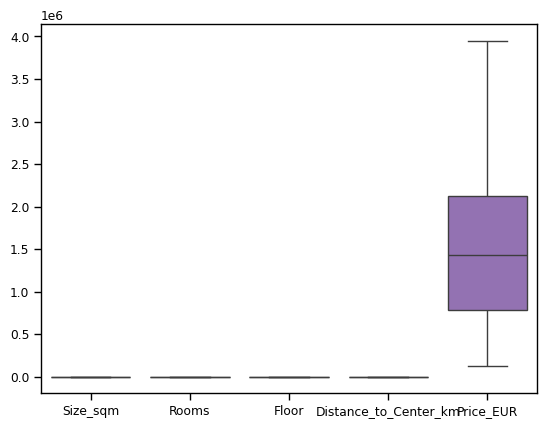

In [240]:
import seaborn as sns
sns.set_context('paper')
sns.boxplot(data=df5[['Size_sqm', 'Rooms', 'Floor', 'Distance_to_Center_km', 'Price_EUR']])

No outliers to remove

Now let's scale some columns

In [241]:
df5.describe()

,Size_sqm,Rooms,Floor,Condition,Distance_to_Center_km,Price_EUR
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1.200000e+03
mean,108.125833,3.000000,4.390833,1.490833,7.755375,1.521459e+06
std,54.176125,1.414214,2.899728,1.129593,4.179961,8.737896e+05
min,15.000000,1.000000,0.000000,0.000000,0.510000,1.205258e+05
25%,62.000000,2.000000,2.000000,0.000000,4.137500,7.847546e+05
50%,108.000000,3.000000,4.000000,1.000000,7.705000,1.430473e+06
75%,157.000000,4.000000,7.000000,3.000000,11.347500,2.125367e+06
max,199.000000,5.000000,9.000000,3.000000,14.990000,3.950832e+06


In [242]:
from sklearn.preprocessing import StandardScaler
stdscale = StandardScaler()

In [243]:
a = df5.iloc[:, 0:5]
b = df5.iloc[:, 6:]
x = a.join(b)
y = df5.iloc[:, 5]

In [244]:
x

,Size_sqm,Rooms,Floor,Condition,Distance_to_Center_km,Property_Type_Loft,Property_Type_Penthouse,Property_Type_Studio
0,117,4,7,3,2.76,False,False,False
1,89,3,3,0,10.77,False,False,True
2,164,5,5,1,3.14,False,False,False
3,35,1,5,2,4.72,False,False,False
4,73,2,2,2,7.96,False,False,True
...,...,...,...,...,...,...,...,...
1195,173,5,5,3,2.42,False,False,True
1196,192,4,1,0,6.56,False,True,False
1197,123,2,7,2,13.18,True,False,False
1198,151,2,1,0,14.43,False,False,True


In [245]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [246]:
x_train_scaled = stdscale.fit_transform(x_train)
x_test_scaled = stdscale.transform(x_test)

In [247]:
model4 = LinearRegression()
model4.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [248]:
predicted4 = model4.predict(x_test_scaled)

In [249]:
x_train_scaled

array([[-0.4395141 ,  0.74377054,  1.24485173, ..., -0.55351275,
         1.6684675 , -0.55167728],
       [-0.3839659 ,  0.74377054,  0.20850341, ...,  1.80664313,
        -0.5993524 , -0.55167728],
       [-0.5506105 ,  1.45052083, -0.48239547, ..., -0.55351275,
        -0.5993524 , -0.55167728],
       ...,
       [-0.45803017,  0.03702025,  1.59030116, ...,  1.80664313,
        -0.5993524 , -0.55167728],
       [ 0.37519281, -0.66973004,  0.20850341, ..., -0.55351275,
        -0.5993524 ,  1.81265393],
       [ 0.35667675,  0.74377054, -1.51874378, ..., -0.55351275,
        -0.5993524 , -0.55167728]], shape=(840, 8))

## Model Evaluation

In [250]:
print(f"MAE: {mean_absolute_error(y_test, predicted4)}")

MAE: 325223.43314623385


In [251]:
print(f"MSE: {mean_squared_error(y_test, predicted4)}")

MSE: 175746900091.9636


In [252]:
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, predicted4))}")

RMSE: 419221.77912408556


In [253]:
print(f"R2 Score: {r2_score(y_test, predicted4)}")

R2 Score: 0.7710590129754522


In [254]:
df4['Price_EUR'].mean()

np.float64(1521458.8519)

Average property price: 1.52 million EUR (15.2 Lakh EUR)

### MAPE (Mean Absolute Percentage Error) <br>
(MAE/ Avg Price) * 100

In [255]:
(mean_absolute_error(y_test, predicted4)/df4['Price_EUR'].mean())*100

np.float64(21.37576265964041)

MAPE: 21.3% <br>meaning my model is off by +- 324k EUR (or 3.24 Lakh EUR) which was calculated by doing 21.3% of 1.52 million